In [20]:
import numpy as np 
import cv2
import matplotlib.pyplot as plt
import os


In [21]:
data_path = os.getenv("DATASETS")+"COVID-19_Radiography_Dataset/Normal/images/"

In [22]:
imagen = cv2.imread(data_path+"Normal-40.png", cv2.IMREAD_GRAYSCALE)

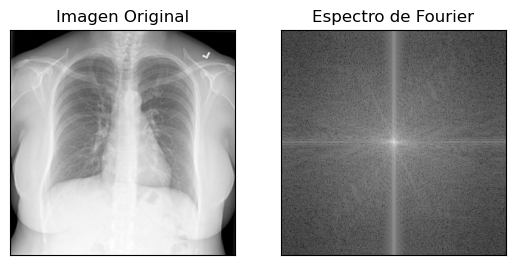

In [37]:
imagen_fourier = np.fft.fft2(imagen)
fftshift = np.fft.fftshift(imagen_fourier)
magnitude_spectrum = 20*np.log(np.abs(fftshift+1e-12))
magnitude_spectrum_visor = (1/(np.max(magnitude_spectrum)-np.min(magnitude_spectrum)))*(magnitude_spectrum-np.min(magnitude_spectrum))

plt.subplot(121),plt.imshow(imagen, cmap = 'gray')
plt.title('Imagen Original'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(magnitude_spectrum_visor, cmap = 'gray')
plt.title('Espectro de Fourier'), plt.xticks([]), plt.yticks([])
plt.savefig("salida.png", dpi=100)
plt.show()

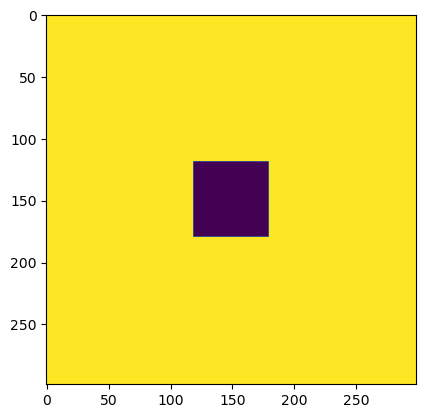

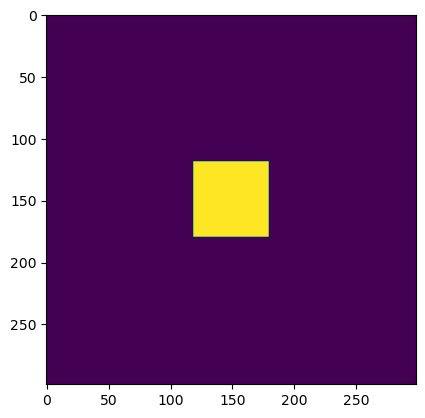

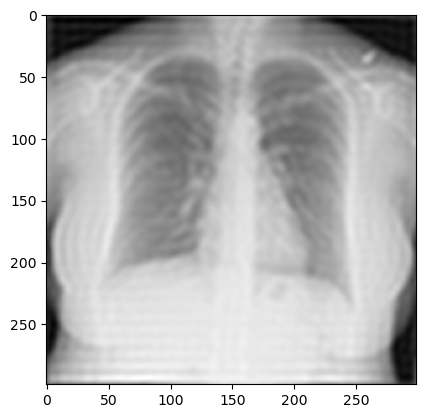

In [34]:
nrows, ncols = fftshift.shape
crows, ccols = nrows//2, ncols//2


mascara = np.ones((nrows,ncols), np.uint8)
mascara[crows-30:crows+31, ccols-30:ccols+31]=0
plt.imshow(mascara)
plt.show()

mascara1 = np.zeros((nrows,ncols), np.uint8)
mascara1[crows-30:crows+31, ccols-30:ccols+31]=1
plt.imshow(mascara1)
plt.show()

new_shift_spectrum = fftshift*mascara1
new_spectrum_= np.fft.ifftshift(new_shift_spectrum)
new_ff_image = np.fft.ifft2(new_spectrum_)
new_imagen = np.real(new_ff_image)
plt.imshow(new_imagen, cmap='gray')

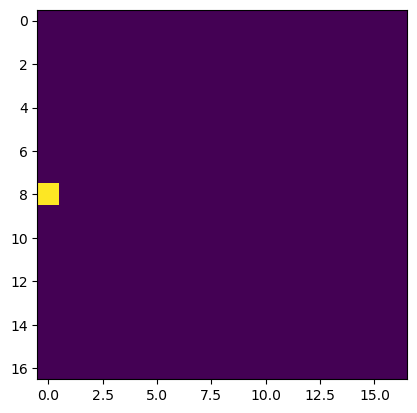

In [57]:
imagen_synt = np.zeros((17,17))
centro_fil = 8
centro_col = 8

imagen_synt[8, 0]=1
imagen_synt[8, 16]=1


imagen_synt[0, 8]=1
imagen_synt[16, 8]=1



plt.imshow(imagen_synt)



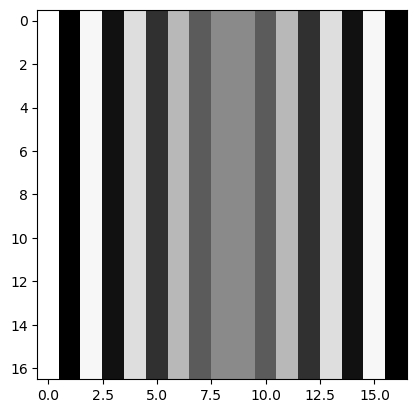

In [58]:
espectro_sintetico= np.fft.ifftshift(imagen_synt)
new_imagen_synt = np.fft.ifft2(espectro_sintetico)
new_imagen = np.real(new_imagen_synt)
plt.imshow(new_imagen, cmap='gray')

(16, 16)

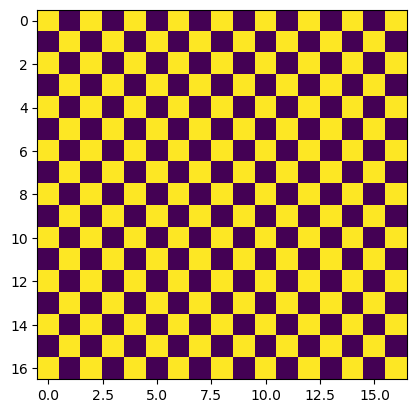

In [65]:
imagen_synt2 = np.zeros((17,17))
for k in range(0,17*17,2):
    imagen_synt2[np.unravel_index(k, imagen_synt2.shape, 'F')]=1

plt.imshow(imagen_synt2)